# Используйте torch или JAX (за JAX от +1 до +4 баллов (в зависимости от качества исполнения и объема) к оценке этой или какой либо другой домашке/докладу (если эта будет сделана на 7-10), т.к. для torch есть готовые реализации)

# ДЕДЛАЙН - 15 МАРТА

# Задание 1

**Основная часть**: 3 балла

**Дополнительная часть**: 3 балла (по 1 баллу за каждую более менее существенную (банальное изменение гиперпараметров не в счет) модификацию)

В статье https://arxiv.org/abs/2106.11959 было показано, что resnet служит неплохим бейзлайном для табличных данных (лекция 7 - слайд 18) и бьет как простые MLP, так и некоторые специализированные архитектуры. Однако по сравнению с MLP в resnet добавляются два компонента: batchnorm и residual connection.

1. Исследуйте необходимы ли оба компонента, чтобы получить преимущество над MLP
2. Попробуйте поменять другие компоненты (dropout, активации, вид нормализации), чтобы улучшить качество (возможно это не получится сделать, поэтому главный критерий здесь - это наличие попытки что то поменять и сравнить, а не сам прирост качества)
3. Сделайте выводы

Для выполнения этих двух задач используйте и модифицируйте (некоторые модификации уже заложены в коде) код из этой библиотеки (mlp и resnet берите оттуда): https://github.com/qile2000/LAMDA-TALENT. Датасеты (достаточно 2-3) можно взять оттуда же, однако убедитесь, что задача достаточно сложная для модели, чтобы было пространство для улучшения (отметайте датасеты с balanced accuracy accuracy>0.9 для классификации и очень маленьким mse/r^2 для регрессии).

**Дополнительно**: попробуйте как то улучшить архитектуру, например, добавить embeddings (например, как в FT transformer - лекция 7, слайд 20, статья: https://arxiv.org/pdf/2106.11959) или заимстовать что то из других архитектур (опять таки, можно вдохновится лекцией 7, устроить pretrain как в VIME или SCARF и т.п.)

In [1]:
import math
import typing as ty

import torch
import numpy as np
import pandas as pd
import random
import re
import matplotlib as plt
import torch.nn as nn
from torch import Tensor
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler, LabelEncoder
from ucimlrepo import fetch_ucirepo
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
from typing import Optional, Union
import delu

import faiss
import faiss.contrib.torch_utils 

import warnings
warnings.filterwarnings('ignore')

In [95]:
random_state = 42

torch.manual_seed(random_state)  
np.random.seed(random_state) 
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


### Возьмем из предложенной библиотеки реализации mlp и resnet

In [22]:
class MLP(nn.Module):
    def __init__(
        self,
        *,
        d_in: int,
        d_out: int, 
        d_layers: ty.List[int],    
        dropout: float,
        
        ) -> None:
        super().__init__()
        self.dropout = dropout
        self.d_out = d_out 
        self.layers = nn.ModuleList(
            [
                nn.Linear(d_layers[i - 1] if i else d_in, x)
                for i, x in enumerate(d_layers)
            ]
        )
        self.head = nn.Linear(d_layers[-1] if d_layers else d_in, d_out)


    def forward(self, x, x_cat = None):
        for layer in self.layers:
            x = layer(x)
            x = F.relu(x)
            if self.dropout:
                x = F.dropout(x, self.dropout, self.training)
        logit = self.head(x)        
        if self.d_out == 1:
            logit = logit.squeeze(-1)
        return  logit

In [157]:
def reglu(x):
    a, b = x.chunk(2, dim=-1)
    return a * F.relu(b)


def geglu(x):
    a, b = x.chunk(2, dim=-1)
    return a * F.gelu(b)

def get_nonglu_activation_fn(name):
    return (
        F.relu
        if name == 'reglu'
        else F.gelu
        if name == 'geglu'
        else get_activation_fn(name)
    )

def get_activation_fn(name):
    return (
        reglu
        if name == 'reglu'
        else geglu
        if name == 'geglu'
        else torch.sigmoid
        if name == 'sigmoid'
        else getattr(F, name)
    )

class ResNet(nn.Module):
    def __init__(
        self,
        *,
        d_in: int,
        d: int,
        d_hidden_factor: float,
        n_layers: int,
        activation: str,
        normalization: str,
        hidden_dropout: float,
        residual_dropout: float,
        d_out: int,
        ) -> None:
        super().__init__()

        def make_normalization():
            return {'batchnorm': nn.BatchNorm1d, 'layernorm': nn.LayerNorm}[
                normalization
                ](d)

        self.main_activation = get_activation_fn(activation)
        self.last_activation = get_nonglu_activation_fn(activation)
        self.residual_dropout = residual_dropout
        self.hidden_dropout = hidden_dropout

        d_hidden = int(d * d_hidden_factor)

        self.first_layer = nn.Linear(d_in, d)
        self.layers = nn.ModuleList(
            [
                nn.ModuleDict(
                    {
                        'norm': make_normalization(),
                        'linear0': nn.Linear(
                            d, d_hidden * (2 if activation.endswith('glu') else 1)
                            ),
                        'linear1': nn.Linear(d_hidden, d),
                    }
                )
                for _ in range(n_layers)
            ]
        )
        self.last_normalization = make_normalization()
        self.head = nn.Linear(d, d_out)

    def forward(self, x: Tensor, x_cat: Tensor = None) -> Tensor:

        x = self.first_layer(x)
        for layer in self.layers:
            layer = ty.cast(ty.Dict[str, nn.Module], layer)
            z = x
            z = layer['norm'](z)
            z = layer['linear0'](z)
            z = self.main_activation(z)
            if self.hidden_dropout:
                z = F.dropout(z, self.hidden_dropout, self.training)
            z = layer['linear1'](z)
            if self.residual_dropout:
                z = F.dropout(z, self.residual_dropout, self.training)
            x = x + z
        x = self.last_normalization(x)
        x = self.last_activation(x)
        x = self.head(x)
        x = x.squeeze(-1)
        return x

В репозитории библиотеки есть файлики с качеством моделей на датасетах, например, для бинарной классификации https://github.com/qile2000/LAMDA-TALENT/blob/main/results/cls_bin.md 

In [224]:
# ф-я для извлечения основного числа (то есть метрики) из строки
def extract_value(cell):
    if isinstance(cell, str):
        cell = cell.replace(' ', '')
        # возьмем число перед знаком '+'
        match = re.match(r'(\d+\.\d+)', cell)
        if match:
            return float(match.group(1))
    return None

def read_md(filename):
    with open(filename, 'r') as file:
        lines = file.readlines()

    table_lines = []
    in_table = False
    for line in lines:
        if line.strip().startswith('|'):
            in_table = True
            table_lines.append(line.strip())
        elif in_table:
            break

    # md в dataframe
    if table_lines:
        cleaned_lines = [re.sub(r'^\||\|$', '', line).split('|') for line in table_lines]
        df = pd.DataFrame(cleaned_lines[1:], columns=[col.strip() for col in cleaned_lines[0]])

        return df
    
    return None

df = read_md('cls_multi.md')        
df = df.drop(0).reset_index(drop=True)
df = df[['Dataset', 'mlp', 'resnet']]
df['mlp'] = df['mlp'].apply(extract_value)
df['resnet'] = df['resnet'].apply(extract_value)
df

,Dataset,mlp,resnet
0,maternal_health_risk,0.7241,0.7629
1,wine-quality-red,0.5867,0.5808
2,yeast,0.6031,0.6034
3,mfeat-morphological,0.7643,0.7642
4,website_phishing,0.8731,0.8873
...,...,...,...
75,gas-drift,0.9941,0.9950
76,Indian_pines,0.9301,0.9463
77,Credit_c,0.7756,0.7698
78,Rain_in_Australia,0.8585,0.8573


In [44]:
f_df = df[(df['mlp'] > 0.7) & (df['mlp'] < 0.8) & (df['resnet'] > 0.7) & (df['resnet'] < 0.8)]
f_df

,Dataset,mlp,resnet
0,maternal_health_risk,0.7241,0.7629
3,mfeat-morphological,0.7643,0.7642
11,led7,0.7397,0.7416
13,BLE_RSSI_dataset_for_Indoor_localization,0.7344,0.7355
19,steel_plates_faults,0.7517,0.7635
24,artificial-characters,0.7810,0.7714
40,predict_students_dropout_and_academic_success,0.7460,0.7478
60,okcupid_stem,0.7450,0.7428
71,accelerometer,0.7382,0.7366
77,Credit_c,0.7756,0.7698


**Возьмем датасет predict_students_dropout_and_academic_success**

In [76]:
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697) 

X = predict_students_dropout_and_academic_success.data.features 
y = predict_students_dropout_and_academic_success.data.targets 

In [16]:
np.unique(y)

array(['Dropout', 'Enrolled', 'Graduate'], dtype=object)

In [77]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)  
y_test = torch.tensor(y_test, dtype=torch.long)

In [19]:
criterion = nn.CrossEntropyLoss()  # для многоклассовой классификации
num_classes = len(np.unique(y_encoded)) 

In [20]:
# для воспроизводимости
def set_seed(seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)

### MLP

In [23]:
set_seed()
model = MLP(d_in=X_train.shape[1], d_out=num_classes, d_layers=[64, 32], dropout=0.2) # d_out должно быть равно количеству классов

optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    

model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    y_pred = torch.argmax(y_pred, dim=1)  

accuracy = accuracy_score(y_test.numpy(), y_pred.numpy())

print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.7559


### Resnet

In [158]:
set_seed()
model = ResNet(
    d_in=X_train.shape[1],  # размерность входных признаков
    d=64,  # размерность скрытого слоя
    d_hidden_factor=2.0,  # множитель для размера скрытого слоя
    n_layers=10,  # кол-во слоев
    activation='relu',  
    normalization='batchnorm',  
    hidden_dropout=0.2,  # Dropout для скрытых слоев
    residual_dropout=0.1,  # Dropout для остаточных связей
    d_out=num_classes  # кол-во выходных классов
)

optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train, x_cat=None)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    

model.eval()
with torch.no_grad():
    y_pred = model(X_test, x_cat=None)
    y_pred = torch.argmax(y_pred, dim=1).numpy()
    
accuracy = accuracy_score(y_test.numpy(), y_pred)

print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.7638


Чтобы понять, насколько важны batchnorm и residual connection, можно поэкспериментировать с их отключением и сравнить результаты
- Только batchnorm: убрать residual connection
- Только residual connection: убрать batchnorm
- Без batchnorm и residual connection: по сути вернуться к базовому MLP 

Все параметры оставим такими же, как и были

In [218]:
class ResNetWithoutComponents(nn.Module):
    def __init__(
        self,
        *,
        d_in: int,
        d: int,
        d_hidden_factor: float,
        n_layers: int,
        activation: str,
        normalization: str,
        hidden_dropout: float,
        residual_dropout: float,
        d_out: int,
        res_conn: bool,  
        batch_norm: bool 
    ) -> None:
        super().__init__()

        def make_normalization():
            return {'batchnorm': nn.BatchNorm1d, 'layernorm': nn.LayerNorm}[normalization](d)
    

        self.main_activation = get_activation_fn(activation)
        self.last_activation = get_nonglu_activation_fn(activation)
        self.residual_dropout = residual_dropout
        self.hidden_dropout = hidden_dropout
        self.res_conn = res_conn  
        self.batch_norm = batch_norm  

        d_hidden = int(d * d_hidden_factor)

        self.first_layer = nn.Linear(d_in, d)
        self.layers = nn.ModuleList(
            [
                nn.ModuleDict(
                    {
                        'norm': make_normalization(),
                        'linear0': nn.Linear(
                            d, d_hidden * (2 if activation.endswith('glu') else 1)
                        ),
                        'linear1': nn.Linear(d_hidden, d),
                    }
                )
                for _ in range(n_layers)
            ]
        )
        self.last_normalization = make_normalization()
        self.head = nn.Linear(d, d_out)

    def forward(self, x: Tensor, x_cat: Tensor) -> Tensor:
        x = self.first_layer(x)
        for layer in self.layers:
            layer = ty.cast(ty.Dict[str, nn.Module], layer)
            z = x
            if self.batch_norm:
                z = layer['norm'](z)  
            z = layer['linear0'](z)
            z = self.main_activation(z)
            if self.hidden_dropout:
                z = F.dropout(z, self.hidden_dropout, self.training)
            z = layer['linear1'](z)
            if self.residual_dropout:
                z = F.dropout(z, self.residual_dropout, self.training)
            if self.res_conn:  # residual connection, если res_conn=True
                x = x + z
            else:
                x = z
        x = self.last_normalization(x)
        x = self.last_activation(x)
        x = self.head(x)
        x = x.squeeze(-1)
        return x

уберем residal connections

In [221]:
set_seed()
model = ResNetWithoutComponents(d_in=X_train.shape[1],  d=64,  d_hidden_factor=2.0,  n_layers=10,  activation='relu',  
                                normalization='batchnorm',  hidden_dropout=0.2,  residual_dropout=0.1, d_out=num_classes,  
    res_conn=False,
    batch_norm=True
)

optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train, x_cat=None)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    

model.eval()
with torch.no_grad():
    y_pred = model(X_test, x_cat=None)
    y_pred = torch.argmax(y_pred, dim=1).numpy()
    
accuracy = accuracy_score(y_test.numpy(), y_pred)

print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.7514


уберем batchnorm

In [222]:
set_seed()
model = ResNetWithoutComponents(d_in=X_train.shape[1],  d=64,  d_hidden_factor=2.0,  n_layers=10,  activation='relu',  
                                normalization='batchnorm',  hidden_dropout=0.2,  residual_dropout=0.1, d_out=num_classes,  
    res_conn=True,
    batch_norm=False
)

optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train, x_cat=None)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    

model.eval()
with torch.no_grad():
    y_pred = model(X_test, x_cat=None)
    y_pred = torch.argmax(y_pred, dim=1).numpy()
    
accuracy = accuracy_score(y_test.numpy(), y_pred)

print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.7616


уберем и то, и то

In [223]:
set_seed()
model = ResNetWithoutComponents(d_in=X_train.shape[1],  d=64,  d_hidden_factor=2.0,  n_layers=10,  activation='relu',  
                                normalization='batchnorm',  hidden_dropout=0.2,  residual_dropout=0.1, d_out=num_classes,  
    res_conn=False,
    batch_norm=False
)

optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train, x_cat=None)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    

model.eval()
with torch.no_grad():
    y_pred = model(X_test, x_cat=None)
    y_pred = torch.argmax(y_pred, dim=1).numpy()
    
accuracy = accuracy_score(y_test.numpy(), y_pred)

print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.7367


Качество получилось хуже, чем просто у resnet

**Попробуем поменять другие компоненты (dropout, активации, вид нормализации), чтобы улучшить качество (возможно это не получится сделать, поэтому главный критерий здесь - это наличие попытки что то поменять и сравнить, а не сам прирост качества)**

**Лучшее качество пока что 0,7638**

In [366]:
def train_rn(criterion, model, X_train, X_test, optimizer, epochs = 50):
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train, x_cat=None)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test, x_cat=None)
        y_pred = torch.argmax(y_pred, dim=1).numpy() 
    accuracy = accuracy_score(y_test.numpy(), y_pred)

    return accuracy

поменяем нормализацию

In [367]:
set_seed()
model = ResNet(
        d_in=X_train.shape[1], d=64,  d_hidden_factor=2.0,  n_layers=10, activation='relu',  
        normalization='layernorm',  hidden_dropout=0.2,  residual_dropout=0.1,  d_out=num_classes 
)

optimizer = optim.Adam(model.parameters(), lr=0.001)
train_rn(criterion, model, X_train, X_test, optimizer)

0.752542372881356

поменяем ф-ю активации

In [388]:
activation_fns = ['relu', 'gelu', 'reglu', 'geglu', 'sigmoid' ]
for f in activation_fns:
        set_seed()
        model = ResNet(
                d_in=X_train.shape[1], d=64,  d_hidden_factor=2.0,  n_layers=10, activation=f,  
                normalization='batchnorm',  hidden_dropout=0.2,  residual_dropout=0.1,  d_out=num_classes 
        )

        optimizer = optim.Adam(model.parameters(), lr=0.001)
        print(f"Функция активации {f}, accuracy {train_rn(criterion, model, X_train, X_test, optimizer)}")

Функция активации relu, accuracy 0.7638418079096045
Функция активации gelu, accuracy 0.7570621468926554
Функция активации reglu, accuracy 0.47231638418079097
Функция активации geglu, accuracy 0.47231638418079097
Функция активации sigmoid, accuracy 0.7581920903954802


Попробуем подобрать параметры, чтоб улучшить качество

In [381]:
import itertools
max_acc = 0.76
dropout_values_res = [0.1, 0.2, 0.3]
dropout_values_hid = [0.1, 0.2, 0.3, 0.4]
d_values = [64, 128]
n_layers_values = [5, 10, 15]

# все комбинации параметров
for dropout, d, n_layers, dropout_h in itertools.product(dropout_values_res, d_values, n_layers_values, dropout_values_hid):
    print(f"Параметры residual_dropout={dropout}, hidden_dropout={dropout_h}, d={d}, n_layers={n_layers}")
    set_seed()
    model = ResNet(
        d_in=X_train.shape[1], d=d,  d_hidden_factor=2.0,  n_layers=n_layers, activation='relu',  
        normalization='batchnorm',  hidden_dropout=dropout_h,  residual_dropout=dropout,  d_out=num_classes 
    )
    
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    acc = train_rn(criterion, model, X_train, X_test, optimizer)
    
    print(f"Accuracy {acc}")
    print("="*40)
    if acc > max_acc:
        best_params = (dropout, d, n_layers, dropout_h)
        max_acc = acc

Параметры residual_dropout=0.1, hidden_dropout=0.1, d=64, n_layers=5
Accuracy 0.7548022598870057
Параметры residual_dropout=0.1, hidden_dropout=0.2, d=64, n_layers=5
Accuracy 0.7548022598870057
Параметры residual_dropout=0.1, hidden_dropout=0.3, d=64, n_layers=5
Accuracy 0.7570621468926554
Параметры residual_dropout=0.1, hidden_dropout=0.4, d=64, n_layers=5
Accuracy 0.7570621468926554
Параметры residual_dropout=0.1, hidden_dropout=0.1, d=64, n_layers=10
Accuracy 0.7502824858757062
Параметры residual_dropout=0.1, hidden_dropout=0.2, d=64, n_layers=10
Accuracy 0.7638418079096045
Параметры residual_dropout=0.1, hidden_dropout=0.3, d=64, n_layers=10
Accuracy 0.751412429378531
Параметры residual_dropout=0.1, hidden_dropout=0.4, d=64, n_layers=10
Accuracy 0.7536723163841808
Параметры residual_dropout=0.1, hidden_dropout=0.1, d=64, n_layers=15
Accuracy 0.751412429378531
Параметры residual_dropout=0.1, hidden_dropout=0.2, d=64, n_layers=15
Accuracy 0.7593220338983051
Параметры residual_dropout

In [382]:
best_params

(0.3, 128, 5, 0.3)

In [387]:
set_seed()
model = ResNet(
        d_in=X_train.shape[1], d=128,  d_hidden_factor=2.0,  n_layers=5, activation='relu',  
        normalization='batchnorm',  hidden_dropout=0.3,  residual_dropout=0.3,  d_out=num_classes 
)

optimizer = optim.Adam(model.parameters(), lr=0.001)
train_rn(criterion, model, X_train, X_test, optimizer)

0.7762711864406779

Получилось улучшить качество, увеличив dropout и размер скрытого слоя и уменьшив количество слоев

## Выводу по подбору параметров 
- ReGLU и GeGLU показывают значительно хуже результаты по сравнению с Relu, Gelu и Sigmoid, возможно это происходит, тк
    - GLU-функции  используются в моделях, где нужно моделировать сложные взаимодействия между признаками (например, в transformer или NLP-задачах), а в resnet они могут быть избыточными, поэтому на них такое плохое качество (меньше 0.5)
    - также требуют  больше данных для обучения, тк они увеличивают сложность модели, а в нашем датасете данных недостаточно (это может привести к переобучению или плохой обобщающей способности)
- Sigmoid показала accuracy, близкую к Relu и Gelu, но она склонна к проблеме затухающих градиентов и ее использование в скрытых слоях не рекомендуется, (она ограничивает выходные значения диапазоном [0, 1], и это может замедлить обучение)
- Получилось улучшить качество, увеличив dropout и размер скрытого слоя и уменьшив количество слоев, возможно, тк
    - если наша модель была склонна к переобучению, то увеличение dropout могло улучшить обобщающую способность модели (тк случайным образом отключаются нейроны, и модель не зависит от конкретных)
    - если наша модель была недостаточно мощной (слишком маленький скрытый слой), то она могла недообучаться, а увеличение размера скрытого слоя помогает лучше улавливать сложные зависимости в данных
    - и если у модели слишком много слоев,то это может привести к проблеме затухающих градиентов и переобучению (=> уменьшение количества слоев могло сделать модель более устойчивой)

### Теперь посмотрим на бинарную классификацию

In [225]:
bin_df = read_md('cls_bin.md')       
bin_df = bin_df.drop(0).reset_index(drop=True)
bin_df = bin_df[['Dataset', 'mlp', 'resnet']]
bin_df['mlp'] = bin_df['mlp'].apply(extract_value)
bin_df['resnet'] = bin_df['resnet'].apply(extract_value)
bin_df

,Dataset,mlp,resnet
0,banknote_authentication,0.5333,0.5287
1,Pima_Indians_Diabetes_Database,0.7606,0.7494
2,Fitness_Club_c,0.7629,0.7756
3,golf_play_dataset_extended,0.8831,0.8992
4,wine,0.7268,0.7259
...,...,...,...
115,madeline,0.6152,0.5938
116,philippine,0.7187,0.7116
117,dabetes_130-us_hospitals,0.6297,0.6314
118,naticusdroid+android+permissions+dataset,0.9687,0.9694


In [ ]:
f_bdf = bin_df[(bin_df['mlp'] > 0.7) & (bin_df['mlp'] < 0.8) & (bin_df['resnet'] > 0.7) & (bin_df['resnet'] < 0.8)]
f_bdf

,Dataset,mlp,resnet
2,Fitness_Club_c,0.7629,0.7756
9,FOREX_audjpy-day-High,0.7304,0.7602
11,FOREX_audcad-day-High,0.7384,0.7480
14,credit-g,0.7330,0.7577
20,Performance-Prediction,0.7211,0.7338
67,telco-customer-churn,0.7936,0.7956
85,KDD,0.7706,0.7717
86,FICO-HELOC-cleaned,0.7325,0.7340
90,Insurance,0.7573,0.7574
96,compass,0.7593,0.7660


Возьмем Fitness_Club_c	

In [3]:
fitness = pd.read_csv('fitness.csv')
fitness

,booking_id,months_as_member,weight,days_before,day_of_week,time,category,attended
0,1,17,79.56,8,Wed,PM,Strength,0
1,2,10,79.01,2,Mon,AM,HIIT,0
2,3,16,74.53,14,Sun,AM,Strength,0
3,4,5,86.12,10,Fri,AM,Cycling,0
4,5,15,69.29,8,Thu,AM,HIIT,0
...,...,...,...,...,...,...,...,...
1495,1496,21,79.51,10,Fri,AM,HIIT,0
1496,1497,29,89.55,2,Mon,AM,Strength,0
1497,1498,9,87.38,4,Tue,AM,HIIT,0
1498,1499,34,68.64,14,Sun,AM,Aqua,0


In [4]:
np.unique(fitness['days_before'])

array(['1', '1 days', '10', '10 days', '11', '12', '12 days', '13',
       '13 days', '14', '14 days', '15', '16', '17', '2', '2 days', '20',
       '29', '3', '3 days', '4', '4 days', '5', '5 days', '6', '6 days',
       '7', '7 days', '8', '8 days', '9'], dtype=object)

In [5]:
def days_to_num(cell):
    if isinstance(cell, str):
        cell = cell.replace(' days', '')
    return int(cell)

fitness['days_before'] = fitness['days_before'].apply(days_to_num)

In [6]:
np.unique(fitness['days_before'])

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       20, 29])

In [7]:
df_encoded = fitness.copy()

label_encoders = {}
for column in ['day_of_week', 'time', 'category']:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])
    label_encoders[column] = le  

X = df_encoded.drop(columns=['booking_id', 'attended']).to_numpy()  # booking_id удаляем, тк это просто номер строки
y = df_encoded['attended'].to_numpy() 
X

array([[17.  , 79.56,  8.  ,  8.  ,  1.  ,  4.  ],
       [10.  , 79.01,  2.  ,  2.  ,  0.  ,  3.  ],
       [16.  , 74.53, 14.  ,  5.  ,  0.  ,  4.  ],
       ...,
       [ 9.  , 87.38,  4.  ,  7.  ,  0.  ,  3.  ],
       [34.  , 68.64, 14.  ,  5.  ,  0.  ,  1.  ],
       [20.  , 94.39,  8.  ,  6.  ,  0.  ,  2.  ]])

In [8]:
y

array([0, 0, 0, ..., 0, 0, 1])

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=14)


X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
# np.sum(y_test)

In [10]:
y_train = y_train[~torch.isnan(X_train).any(dim=1)]
X_train = X_train[~torch.isnan(X_train).any(dim=1)]

In [11]:
torch.isnan(X_train).sum()

tensor(0)

#### MLP

In [394]:
criterion = nn.BCEWithLogitsLoss()  # для бинарной классификации

set_seed()
model = MLP(d_in=X_train.shape[1], d_out=1, d_layers=[64, 32], dropout=0.1)  # d_out=1 для бинарной классификации

optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs.squeeze(), y_train)  
    loss.backward()
    optimizer.step()
    
model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    y_pred = torch.sigmoid(y_pred)  # logits в вероятности
    y_pred = (y_pred >= 0.5).float()  # округляем вероятности до 0 или 1

accuracy = accuracy_score(y_test.numpy(), y_pred.numpy())

print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.8311


#### Resnet

In [405]:
set_seed()
model = ResNet(
    d_in=X_train.shape[1], 
    d=64,  
    d_hidden_factor=3.0, 
    n_layers=10,
    activation='relu',  
    normalization='batchnorm',  
    hidden_dropout=0.2,  
    residual_dropout=0.1,  
    d_out=1
)

optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train, x_cat=None)
    loss = criterion(outputs.squeeze(), y_train)
    loss.backward()
    optimizer.step()


model.eval()
with torch.no_grad():
    y_pred = model(X_test, x_cat=None)
    y_pred = torch.sigmoid(y_pred)  
    y_pred = (y_pred > 0.5).float() 
    
accuracy = accuracy_score(y_test.numpy(), y_pred)

print(f'Accuracy: {accuracy}')

Accuracy: 0.84


уберем residual connections

In [357]:
set_seed()
model = ResNetWithoutComponents(d_in=X_train.shape[1],  d=64,  d_hidden_factor=2.0,  n_layers=10,  activation='relu',  
                                normalization='batchnorm',  hidden_dropout=0.2,  residual_dropout=0.1, d_out=1,  
    res_conn=False,
    batch_norm=True
)

optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train, x_cat=None)
    loss = criterion(outputs.squeeze(), y_train)
    loss.backward()
    optimizer.step()
    
model.eval()
with torch.no_grad():
    y_pred = model(X_test, x_cat=None)
    y_pred = torch.sigmoid(y_pred)  
    y_pred = (y_pred > 0.5).float() 
    
accuracy = accuracy_score(y_test.numpy(), y_pred)

print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.8311


уберем batchnorm

In [358]:
set_seed()
model = ResNetWithoutComponents(d_in=X_train.shape[1],  d=64,  d_hidden_factor=2.0,  n_layers=10,  activation='relu',  
                                normalization='batchnorm',  hidden_dropout=0.2,  residual_dropout=0.1, d_out=1,  
    res_conn=True,
    batch_norm=False
)

optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train, x_cat=None)
    loss = criterion(outputs.squeeze(), y_train)
    loss.backward()
    optimizer.step()
    
model.eval()
with torch.no_grad():
    y_pred = model(X_test, x_cat=None)
    y_pred = torch.sigmoid(y_pred)  
    y_pred = (y_pred > 0.5).float() 
    
accuracy = accuracy_score(y_test.numpy(), y_pred)

print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.8178


уберем и то, и то

In [402]:
set_seed()
model = ResNetWithoutComponents(d_in=X_train.shape[1],  d=64,  d_hidden_factor=2.0,  n_layers=10,  activation='relu',  
                                normalization='batchnorm',  hidden_dropout=0.2,  residual_dropout=0.1, d_out=1,  
    res_conn=False,
    batch_norm=False
)

optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train, x_cat=None)
    loss = criterion(outputs.squeeze(), y_train)
    loss.backward()
    optimizer.step()
    
model.eval()
with torch.no_grad():
    y_pred = model(X_test, x_cat=None)
    y_pred = torch.sigmoid(y_pred)  
    y_pred = (y_pred > 0.5).float() 
    
accuracy = accuracy_score(y_test.numpy(), y_pred)

print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.8178


опять-таки получилось хуже, чем с обоими компонентами (параметры все остальные остались те же)

**Попробуем поменять другие компоненты (dropout, активации, вид нормализации), чтобы улучшить качество (возможно это не получится сделать, поэтому главный критерий здесь - это наличие попытки что то поменять и сравнить, а не сам прирост качества)**

**Лучшее качество пока что 0,84**

In [395]:
def train_rn_bin(criterion, model, X_train, X_test, optimizer, epochs = 50):
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train, x_cat=None)
        loss = criterion(outputs.squeeze(), y_train)
        loss.backward()
        optimizer.step()
        
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test, x_cat=None)
        y_pred = torch.sigmoid(y_pred)  
        y_pred = (y_pred > 0.5).float() 
    accuracy = accuracy_score(y_test.numpy(), y_pred)

    return accuracy

поменяем нормализацию

In [406]:
set_seed()
model = ResNet(
        d_in=X_train.shape[1], d=64,  d_hidden_factor=2.0,  n_layers=10, activation='relu',  
        normalization='layernorm',  hidden_dropout=0.2,  residual_dropout=0.1,  d_out=1 
)

optimizer = optim.Adam(model.parameters(), lr=0.001)
train_rn_bin(criterion, model, X_train, X_test, optimizer)

0.8088888888888889

поменяем ф-ю активации

In [407]:
activation_fns = ['relu', 'gelu', 'reglu', 'geglu', 'sigmoid' ]
for f in activation_fns:
        set_seed()
        model = ResNet(
                d_in=X_train.shape[1], d=64,  d_hidden_factor=2.0,  n_layers=10, activation=f,  
                normalization='batchnorm',  hidden_dropout=0.2,  residual_dropout=0.1,  d_out=1 
        )

        optimizer = optim.Adam(model.parameters(), lr=0.001)
        print(f"Функция активации {f}, accuracy {train_rn_bin(criterion, model, X_train, X_test, optimizer)}")

Функция активации relu, accuracy 0.84
Функция активации gelu, accuracy 0.84
Функция активации reglu, accuracy 0.8355555555555556
Функция активации geglu, accuracy 0.8222222222222222
Функция активации sigmoid, accuracy 0.8222222222222222


Попробуем подобрать параметры, чтоб улучшить качество

In [408]:
max_acc = 0.84
dropout_values_res = [0.1, 0.2, 0.3]
dropout_values_hid = [0.1, 0.2, 0.3, 0.4]
d_values = [64, 128]
n_layers_values = [5, 10, 15]

# все комбинации параметров
for dropout, d, n_layers, dropout_h in itertools.product(dropout_values_res, d_values, n_layers_values, dropout_values_hid):
    print(f"Параметры residual_dropout={dropout}, hidden_dropout={dropout_h}, d={d}, n_layers={n_layers}")
    set_seed()
    model = ResNet(
        d_in=X_train.shape[1], d=d,  d_hidden_factor=2.0,  n_layers=n_layers, activation='relu',  
        normalization='batchnorm',  hidden_dropout=dropout_h,  residual_dropout=dropout,  d_out=1 
    )
    
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    acc = train_rn_bin(criterion, model, X_train, X_test, optimizer)
    
    print(f"Accuracy {acc}")
    print("="*40)
    if acc > max_acc:
        best_params = (dropout, d, n_layers, dropout_h)
        max_acc = acc

Параметры residual_dropout=0.1, hidden_dropout=0.1, d=64, n_layers=5
Accuracy 0.8266666666666667
Параметры residual_dropout=0.1, hidden_dropout=0.2, d=64, n_layers=5
Accuracy 0.8266666666666667
Параметры residual_dropout=0.1, hidden_dropout=0.3, d=64, n_layers=5
Accuracy 0.8266666666666667
Параметры residual_dropout=0.1, hidden_dropout=0.4, d=64, n_layers=5
Accuracy 0.8266666666666667
Параметры residual_dropout=0.1, hidden_dropout=0.1, d=64, n_layers=10
Accuracy 0.84
Параметры residual_dropout=0.1, hidden_dropout=0.2, d=64, n_layers=10
Accuracy 0.84
Параметры residual_dropout=0.1, hidden_dropout=0.3, d=64, n_layers=10
Accuracy 0.84
Параметры residual_dropout=0.1, hidden_dropout=0.4, d=64, n_layers=10
Accuracy 0.84
Параметры residual_dropout=0.1, hidden_dropout=0.1, d=64, n_layers=15
Accuracy 0.8444444444444444
Параметры residual_dropout=0.1, hidden_dropout=0.2, d=64, n_layers=15
Accuracy 0.84
Параметры residual_dropout=0.1, hidden_dropout=0.3, d=64, n_layers=15
Accuracy 0.84
Параметры 

In [409]:
best_params

(0.1, 128, 5, 0.2)

In [410]:
set_seed()
model = ResNet(
    d_in=X_train.shape[1], d=128,  d_hidden_factor=2.0,  n_layers=5, activation='relu',  
    normalization='batchnorm',  hidden_dropout=0.2,  residual_dropout=0.1,  d_out=1 
)

optimizer = optim.Adam(model.parameters(), lr=0.001)
acc = train_rn_bin(criterion, model, X_train, X_test, optimizer)

print(f"Accuracy {acc}")

Accuracy 0.8488888888888889


Получилось немного улучшить качество (примерно на 0.009), уменьшив количество слоев и увеличив размер скрытого слоя

### Выводу по подбору параметров 

- Обе функции Relu и gelu показывают одинаковую точность 0.84, что ожидаемо, так как Relu и Gelu являются стандартными и хорошо работают во многих не сильно сложных задачах
- Точность ReGLU  немного ниже 0.8355, что может быть связано с теми же причинами, что и в первом датасете 
- у GeGLU и Sigmoid точность еще ниже 0.82222 тоже по тем же причинам (Sigmoid страдает от проблемы "затухания градиента" )
- Поэтому, тк модель простая, Relu может быть предпочтительнее из-за своей вычислительной эффективности
- Получилось немного улучшить качество (примерно на 0.009), уменьшив количество слоев и увеличив размер скрытого слоя тоже по причинам, описанным выше (уменьшение количества слоев может привести к упрощению модели, что иногда помогает избежать переобучения,а увеличение размера скрытого слоя позволяет модели лучше улавливать сложные зависимости в данных)


## Выводы про необходимость residual connections и batchnorm

- В основе batchnorm лежит решение проблемы «внутреннего ковариационного сдвига» (нормализация слоев гарантирует, что функция активации остается в постоянном диапазоне, что стабилизирует процесс обучения), но batchnorm не решает проблему затухающих градиентов, в отличие от residual connections, поэтобу без RC может быть хуже качество
- residual connections позволяют избежать проблемы затухающих градиентов (`+ x` позволяет не занулить)
- batchnorm уменьшает изменение распределения входных данных для каждого слоя, что облегчает обучение глубоких сетей, поэтому без него
   - Может быть нестабильность градиентов 
   - Обучение может замедляться, тк градиенты будут либо слишком большими, либо слишком маленькими (проблема затухающих/взрывающихся градиентов)
   - Модель может хуже обобщать, особенно если данные имеют большой разброс по масштабу в разных батчах
- Использование residual connections без batchnorm: есть [статья](https://openreview.net/pdf?id=ryxB0Rtxx), в которой авторы  провели эксперименты с упрощённой архитектурой, которая использует только residual connections и relu-активации, но без batchnorm, dropout или max pooling, и  несмотря на отсутствие этих компонентов, их модель показала неплохие результаты на данных CIFAR10, CIFAR100 и ImageNet (на CIFAR10 модель  лучше, чем предыдущие сети, на CIFAR100 лучше, чем некоторые предыдущие модели, на ImageNet модель хуже, чем предыдущие сети с batchnorm).В статье показано, что residual connections сами по себе могут обеспечить хорошее качество даже без batchnorm, особенно на относительно простых задачах (например, CIFAR10 и CIFAR100), но на сложных задачах со сложными данными batchnorm помогает для улучшения сходимости и качества модели
- **Итого** batchnorm стабилизирует обучение на уровне каждого слоя, а residual connections упрощают передачу градиентов через всю сеть, поэтому вместе они позволяют обучать глубокие сети на данных, для которых сети без этих компонентов могли бы быть неустойчивыми или вовсе не обучаться
(нормализация слоев и остаточные связи вместе улучшают точность и обобщение)




# Дополнительная часть
3 балла (по 1 баллу за каждую более менее существенную (банальное изменение гиперпараметров не в счет) модификацию)

Попробуйте как-то улучшить архитектуру, например, добавить embeddings (например, как в FT transformer - лекция 7, слайд 20, статья: https://arxiv.org/pdf/2106.11959) или заимстовать что-то из других архитектур (опять-таки, можно вдохновится лекцией 7, устроить pretrain как в VIME или SCARF и т.п.)

### Добавим MultiheadAttention

In [72]:
class ResNetMH(nn.Module):
    def __init__(
        self,
        *,
        d_in: int,
        d: int,
        d_hidden_factor: float,
        n_layers: int,
        activation: str,
        normalization: str,
        hidden_dropout: float,
        residual_dropout: float,
        d_out: int,
        num_heads: int,
    ) -> None:
        super().__init__()

        def make_normalization():
            return {'batchnorm': nn.BatchNorm1d, 'layernorm': nn.LayerNorm}[
                normalization
            ](d)

        self.main_activation = get_activation_fn(activation)
        self.last_activation = get_nonglu_activation_fn(activation)
        self.residual_dropout = residual_dropout
        self.hidden_dropout = hidden_dropout

        d_hidden = int(d * d_hidden_factor)

        self.first_layer = nn.Linear(d_in, d)
        self.layers = nn.ModuleList(
            [
                nn.ModuleDict(
                    {
                        'norm': make_normalization(),
                        'linear0': nn.Linear(
                            d, d_hidden * (2 if activation.endswith('glu') else 1)
                        ),
                        'linear1': nn.Linear(d_hidden, d),
                        'attention': nn.MultiheadAttention(d, num_heads=num_heads) 
                    }
                )
                for _ in range(n_layers)
            ]
        )
        self.last_normalization = make_normalization()
        self.head = nn.Linear(d, d_out)

    def forward(self, x: Tensor, x_cat: Tensor = None) -> Tensor:
        x = self.first_layer(x)
        for layer in self.layers:
            layer = layer  
            z = x
            z = layer['norm'](z)
            z = layer['linear0'](z)
            z = self.main_activation(z)
            if self.hidden_dropout:
                z = F.dropout(z, self.hidden_dropout, self.training)
            z = layer['linear1'](z)
            z_attn, _ = layer['attention'](z.unsqueeze(0), z.unsqueeze(0), z.unsqueeze(0))
            z = z + z_attn.squeeze(0)
            if self.residual_dropout:
                z = F.dropout(z, self.residual_dropout, self.training)
            x = x + z
        x = self.last_normalization(x)
        x = self.last_activation(x)
        x = self.head(x)
        x = x.squeeze(-1)
        return x

In [146]:
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697)
X = predict_students_dropout_and_academic_success.data.features
y = predict_students_dropout_and_academic_success.data.targets
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [74]:
criterion = nn.CrossEntropyLoss()
num_classes = len(np.unique(y_encoded))

set_seed()
model = ResNetMH(
    d_in=X_train.shape[1],
    d=64,
    d_hidden_factor=2.0,
    n_layers=10,
    activation='relu',
    normalization='batchnorm',
    hidden_dropout=0.2,
    residual_dropout=0.1,
    d_out=num_classes,
    num_heads=2
)

optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    y_pred = torch.argmax(y_pred, dim=1).numpy()

accuracy = accuracy_score(y_test.numpy(), y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.7695


получили точность чуть выше, чем была просто у resnet (была 0,7638)

### Используем residual connections с weighted sum
Вместо простого сложения в residual connections, можно использовать взвешенную сумму, где веса обучаются в процессе обучения

In [86]:
class WeightedResNet(ResNet):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.weights = nn.Parameter(torch.ones(kwargs['n_layers']))

    def forward(self, x: Tensor, x_cat: Tensor = None) -> Tensor:
        x = self.first_layer(x)
        for i, layer in enumerate(self.layers):
            layer = ty.cast(ty.Dict[str, nn.Module], layer)
            z = x
            z = layer['norm'](z)
            z = layer['linear0'](z)
            z = self.main_activation(z)
            if self.hidden_dropout:
                z = F.dropout(z, self.hidden_dropout, self.training)
            z = layer['linear1'](z)
            if self.residual_dropout:
                z = F.dropout(z, self.residual_dropout, self.training)
            x = x + self.weights[i] * z  # вместо обычного resconn получаем взвешенную сумму
        x = self.last_normalization(x)
        x = self.last_activation(x)
        x = self.head(x)
        x = x.squeeze(-1)
        return x

In [ ]:
set_seed()
model = WeightedResNet(
    d_in=X_train.shape[1],  
    d=64,
    d_hidden_factor=2.0,
    n_layers=10,
    activation='relu',
    normalization='batchnorm',
    hidden_dropout=0.2,
    residual_dropout=0.1,
    d_out=num_classes,
)

optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()


model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    y_pred = torch.argmax(y_pred, dim=1).numpy()

accuracy = accuracy_score(y_test.numpy(), y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.7650


качество получилось тоже чуть лучше, чем при обычной resnet (с теми же параметрами)

**Посмотрим на важность признаков с помощью метода Permutation Importance**

Суть  метода: случайным образом переставлять значения каждого признака и измерять, насколько ухудшается качество модели. Если после перестановки признака качество модели значительно падает, то это указывает на важность этого признака

In [ ]:
from skorch import NeuralNetClassifier

# обертываем модель в skorch, чтобы была cовместимость с sklearn 
model_skorch = NeuralNetClassifier(
    module=model,  
    criterion=torch.nn.CrossEntropyLoss,  
    optimizer=torch.optim.Adam, 
    lr=0.001,  
    max_epochs=10,  
)


model_skorch.fit(X_train.numpy(), y_train.numpy())

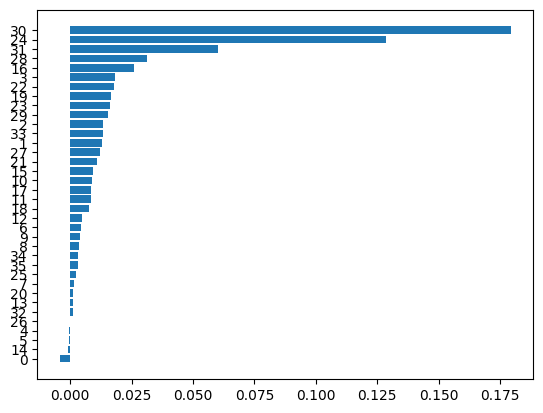

In [177]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model_skorch, 
    X_test.numpy(), 
    y_test.numpy(), 
    n_repeats=10, 
    random_state=42
)

sorted_idx = result.importances_mean.argsort()
plt.barh(range(X_test.shape[1]), result.importances_mean[sorted_idx])
plt.yticks(range(X_test.shape[1]), sorted_idx)
plt.show()

### Добавим Squeeze-and-Excitation блоки

Squeeze-and-Excitation блоки позволяют перевзвешивать признаки в зависимости от их важности, что должно помочь, тк у нас некоторые признаки более значимы, чем другие

In [113]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.unsqueeze(-1)  # (batch_size, channels, 1) 
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        x = x * y.expand_as(x)
        x = x.squeeze(-1)  
        return x
    
class ResNetSE(nn.Module):
    def __init__(
        self,
        *,
        d_in: int,
        d: int,
        d_hidden_factor: float,
        n_layers: int,
        activation: str,
        normalization: str,
        hidden_dropout: float,
        residual_dropout: float,
        d_out: int,
    ) -> None:
        super().__init__()

        def make_normalization():
            return {'batchnorm': nn.BatchNorm1d, 'layernorm': nn.LayerNorm}[
                normalization
            ](d)

        self.main_activation = get_activation_fn(activation)
        self.last_activation = get_nonglu_activation_fn(activation)
        self.residual_dropout = residual_dropout
        self.hidden_dropout = hidden_dropout

        d_hidden = int(d * d_hidden_factor)

        self.first_layer = nn.Linear(d_in, d)
        self.layers = nn.ModuleList(
            [
                nn.ModuleDict(
                    {
                        'norm': make_normalization(),
                        'linear0': nn.Linear(
                            d, d_hidden * (2 if activation.endswith('glu') else 1)
                        ),
                        'linear1': nn.Linear(d_hidden, d),
                        'se': SEBlock(d) 
                    }
                )
                for _ in range(n_layers)
            ]
        )
        self.last_normalization = make_normalization()
        self.head = nn.Linear(d, d_out)

    def forward(self, x: Tensor, x_cat: Tensor = None) -> Tensor:
        x = self.first_layer(x)
        for layer in self.layers:
            layer = ty.cast(ty.Dict[str, nn.Module], layer)
            z = x
            z = layer['norm'](z)
            z = layer['linear0'](z)
            z = self.main_activation(z)
            if self.hidden_dropout:
                z = F.dropout(z, self.hidden_dropout, self.training)
            z = layer['linear1'](z)
            z = layer['se'](z) 
            if self.residual_dropout:
                z = F.dropout(z, self.residual_dropout, self.training)
            x = x + z
        x = self.last_normalization(x)
        x = self.last_activation(x)
        x = self.head(x)
        x = x.squeeze(-1)
        return x

In [ ]:
set_seed()
model = ResNetSE(
    d_in=X_train.shape[1],  
    d=64,
    d_hidden_factor=2.0,
    n_layers=10,
    activation='relu',
    normalization='batchnorm',
    hidden_dropout=0.2,
    residual_dropout=0.1,
    d_out=num_classes,
)

optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    y_pred = torch.argmax(y_pred, dim=1).numpy()

accuracy = accuracy_score(y_test.numpy(), y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.7661


тоже чуть увеличили точность по сравнению с обычной resnet

### Выводы

ИТак, мы смогли совсем немного увеличить точность по сравнению с обычной resnet(с теми же параметрами), но это увеличение совсем небольшое и даже хуже точности обычной resnet с подобранными гиперпараметрами

Возможные причины
- Добавление сложных механизмов увеличивает количество параметров модели, что может привести к переобучению, особенно если данных недостаточно (как в нашем датасете) для обучения таких параметров
- Также добавление новых механизмов может усложнить процесс обучения (например, градиенты могут становиться слишком маленькими или слишком большими, что затрудняет сходимость)
-  Multihead Attention, лучше работает на последовательностях или данных с явной структурой зависимостей, а для табличных данных они могут быть избыточными

В целом, resnet уже мощная архитектура, и её производительность может быть близка к пределу для данного набора данных и поэтому,возможно,  получилось так, что добавление сложных механизмов не дало значительного улучшения